# Layer 2: Drill-Down Analysis (어디가 원인인가?)

## Why This Analysis Matters
When the Layer 1 dashboard flags an anomaly, you need to isolate the root cause
before making any intervention decision. This notebook provides structured drill-downs
across four dimensions:

1. **GMV Decomposition** — which categories or regions are driving a GMV shift?
2. **Seller-Side Health** — churn, new acquisition, listing quality
3. **Buyer-Side Health** — cohort retention, purchase funnel
4. **Matching Efficiency** — how well supply meets demand at the category level


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

orders        = pd.read_csv('../data/olist_orders_dataset.csv',
    parse_dates=['order_purchase_timestamp','order_delivered_customer_date'])
order_items   = pd.read_csv('../data/olist_order_items_dataset.csv')
customers     = pd.read_csv('../data/olist_customers_dataset.csv')
sellers       = pd.read_csv('../data/olist_sellers_dataset.csv')
products      = pd.read_csv('../data/olist_products_dataset.csv')
reviews       = pd.read_csv('../data/olist_order_reviews_dataset.csv')
category_trans= pd.read_csv('../data/product_category_name_translation.csv')

# Build enriched orders table used throughout this notebook
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

items_cat = (order_items
    .merge(products[['product_id','product_category_name']], on='product_id', how='left')
    .merge(category_trans, on='product_category_name', how='left'))
items_cat['category'] = (items_cat['product_category_name_english']
                         .fillna(items_cat['product_category_name']))

base = (orders.merge(order_items[['order_id','price','seller_id']], on='order_id')
              .merge(customers[['customer_id','customer_unique_id','customer_state']],
                     on='customer_id'))
base = base.merge(items_cat[['order_id','category']].drop_duplicates(), on='order_id', how='left')

print(f"Enriched base table: {len(base):,} rows")


Enriched base table: 114,625 rows


## 2.1 GMV Decomposition by Category

When GMV drops, the first question is: **which categories are falling?**
Here we plot the monthly GMV contribution per category for the top 10.


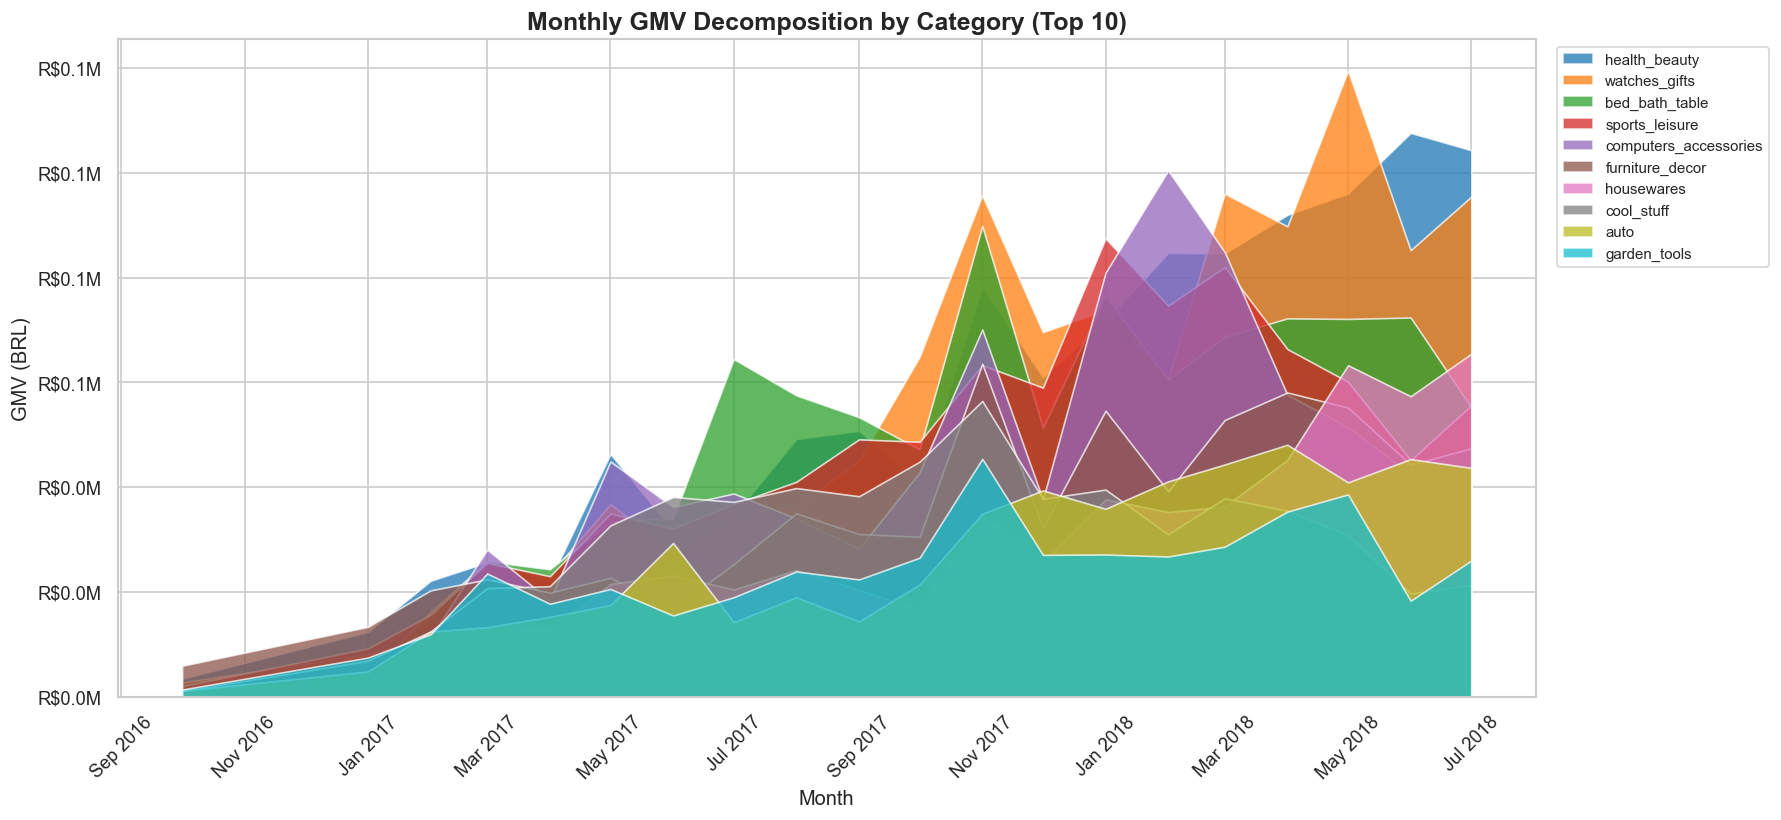

In [11]:
top_cats = (base[base['order_status']=='delivered']
            .groupby('category')['price'].sum()
            .nlargest(10).index.tolist())

gmv_cat = (base[(base['order_status']=='delivered') &
                (base['category'].isin(top_cats))]
           .groupby(['month','category'])['price']
           .sum().reset_index(name='gmv'))

# Trim partial months
gmv_cat = gmv_cat[
    (gmv_cat['month'] > gmv_cat['month'].min()) &
    (gmv_cat['month'] < gmv_cat['month'].max())]

fig, ax = plt.subplots(figsize=(15, 7))
colors = plt.cm.tab10.colors
for i, cat in enumerate(top_cats):
    sub = gmv_cat[gmv_cat['category'] == cat]
    ax.stackplot(sub['month'], sub['gmv'], labels=[cat], colors=[colors[i]], alpha=0.75)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('Monthly GMV Decomposition by Category (Top 10)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('GMV (BRL)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../images/gmv_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.2 GMV Decomposition by Region

Regional variation matters for logistics and seller network planning.
We look at GMV share by state and flag states with declining contribution.


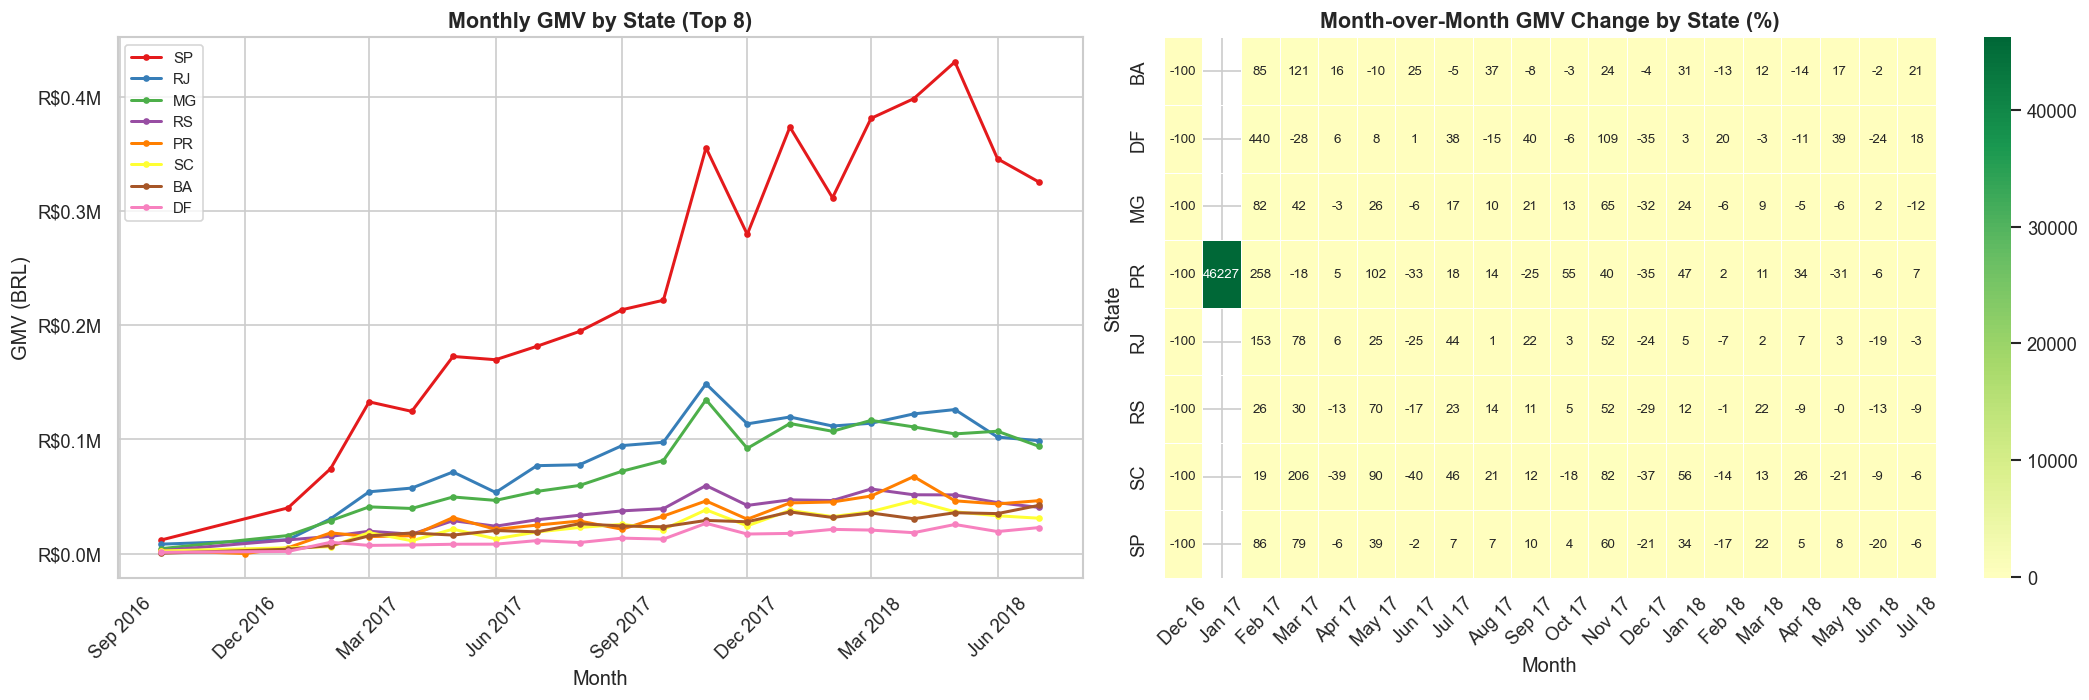

In [12]:
gmv_state = (base[base['order_status']=='delivered']
             .groupby(['month','customer_state'])['price']
             .sum().reset_index(name='gmv'))

top_states = (base[base['order_status']=='delivered']
              .groupby('customer_state')['price'].sum()
              .nlargest(8).index.tolist())

gmv_state_top = gmv_state[
    (gmv_state['customer_state'].isin(top_states)) &
    (gmv_state['month'] > gmv_state['month'].min()) &
    (gmv_state['month'] < gmv_state['month'].max())]

# MoM % change heatmap
pivot = gmv_state_top.pivot(index='customer_state', columns='month', values='gmv').fillna(0)
pct_change = pivot.pct_change(axis=1).iloc[:, 1:] * 100
# inf arises when previous month GMV was 0; treat as missing
pct_change = pct_change.replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: absolute GMV
for i, state in enumerate(top_states):
    sub = gmv_state_top[gmv_state_top['customer_state'] == state]
    axes[0].plot(sub['month'], sub['gmv'], marker='.', linewidth=1.8,
                 label=state, color=plt.cm.Set1.colors[i % 9])
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
axes[0].set_title('Monthly GMV by State (Top 8)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('GMV (BRL)')
axes[0].legend(fontsize=9)

# Right: MoM % heatmap
annot_labels = pct_change.map(lambda x: f'{x:.0f}' if pd.notna(x) else '')
sns.heatmap(pct_change, ax=axes[1], cmap='RdYlGn', center=0, fmt='',
            annot=annot_labels, annot_kws={'size': 8}, linewidths=0.4,
            xticklabels=[m.strftime('%b %y') for m in pct_change.columns])
axes[1].set_title('Month-over-Month GMV Change by State (%)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('State')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../images/gmv_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Seller-Side Health: Churn, Acquisition, Listing Quality

**Seller cohort definitions:**
- **New seller:** first month they appear in `order_items`
- **Active seller:** sold ≥1 item that month
- **Churned seller:** was active in previous month, not active this month
- **Churn rate:** churned sellers / active sellers in prior month

**Listing quality proxy:** avg review score + fulfillment rate (delivered / total orders).


In [13]:
# Build monthly seller activity table
seller_months = (base.groupby(['seller_id','year_month'])
                 .agg(orders=('order_id','nunique'), gmv=('price','sum'))
                 .reset_index())
seller_months['month'] = seller_months['year_month'].dt.to_timestamp()

# First active month per seller
seller_first = seller_months.groupby('seller_id')['year_month'].min().reset_index()
seller_first.columns = ['seller_id','first_month']
seller_months = seller_months.merge(seller_first, on='seller_id')

# New sellers per month
new_sellers = (seller_months[seller_months['year_month'] == seller_months['first_month']]
               .groupby('month').size().reset_index(name='new_sellers'))

# Churn: present in month t-1, absent in month t
all_periods = sorted(seller_months['year_month'].unique())
churn_rows = []
for i in range(1, len(all_periods)):
    prev, curr = all_periods[i-1], all_periods[i]
    prev_sellers = set(seller_months[seller_months['year_month']==prev]['seller_id'])
    curr_sellers = set(seller_months[seller_months['year_month']==curr]['seller_id'])
    churned = len(prev_sellers - curr_sellers)
    churn_rate = churned / len(prev_sellers) if prev_sellers else 0
    churn_rows.append({'month': curr.to_timestamp(), 'churned': churned,
                       'churn_rate': churn_rate, 'active': len(curr_sellers)})

churn_df = pd.DataFrame(churn_rows).iloc[:-1]  # trim last partial month
new_sellers = new_sellers[(new_sellers['month'] > new_sellers['month'].min()) &
                           (new_sellers['month'] < new_sellers['month'].max())]

print("Seller churn stats:")
print(churn_df[['month','active','churned','churn_rate']].to_string(index=False))


Seller churn stats:
     month  active  churned  churn_rate
2016-10-01     143        1    0.333333
2016-12-01       1      143    1.000000
2017-01-01     227        0    0.000000
2017-02-01     427       55    0.242291
2017-03-01     499      129    0.302108
2017-04-01     506      150    0.300601
2017-05-01     583      127    0.250988
2017-06-01     539      193    0.331046
2017-07-01     606      143    0.265306
2017-08-01     708      129    0.212871
2017-09-01     731      193    0.272599
2017-10-01     776      199    0.272230
2017-11-01     965      165    0.212629
2017-12-01     861      296    0.306736
2018-01-01     970      205    0.238095
2018-02-01     947      256    0.263918
2018-03-01     996      223    0.235480
2018-04-01    1123      225    0.225904
2018-05-01    1115      308    0.274265
2018-06-01    1175      312    0.279821
2018-07-01    1261      317    0.269787
2018-08-01    1278      350    0.277557


In [14]:
seller_quality = (base[base['order_status']=='delivered']
    .merge(reviews[['order_id','review_score']], on='order_id', how='left')
    .groupby('seller_id')
    .agg(
        total_orders   = ('order_id','nunique'),
        fulfilled      = ('order_status', lambda x: (x=='delivered').sum()),
        avg_review     = ('review_score','mean'),
    ).reset_index())
seller_quality['fulfillment_rate'] = seller_quality['fulfilled'] / seller_quality['total_orders']
# Quality score = simple average of normalized review (0-1) and fulfillment rate
seller_quality['quality_score'] = (
    (seller_quality['avg_review'] / 5) * 0.5 +
     seller_quality['fulfillment_rate'] * 0.5)

print(f"Median seller quality score: {seller_quality['quality_score'].median():.3f}")
print(seller_quality[['avg_review','fulfillment_rate','quality_score']].describe().round(3))


Median seller quality score: 0.976
       avg_review  fulfillment_rate  quality_score
count    2965.000          2970.000       2965.000
mean        4.137             1.186          1.007
std         0.806             0.473          0.238
min         1.000             1.000          0.600
25%         3.875             1.000          0.927
50%         4.251             1.020          0.976
75%         4.700             1.190          1.005
max         5.000            15.000          8.000


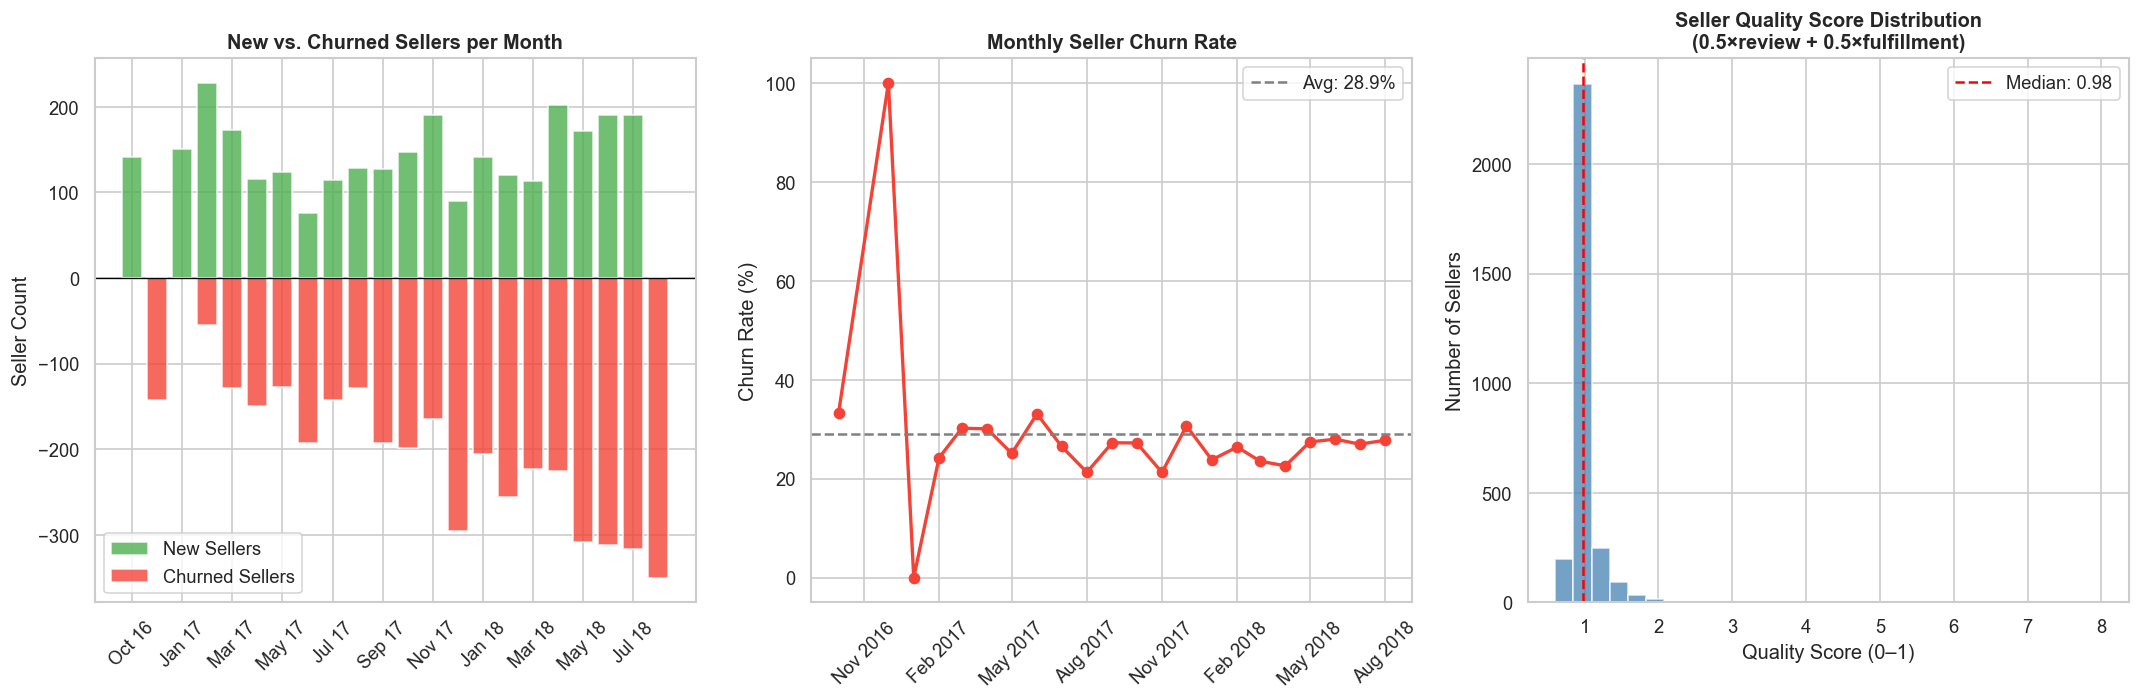

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# New vs churned sellers
churn_new = churn_df.merge(new_sellers, on='month', how='left').fillna(0)
x = range(len(churn_new))
axes[0].bar(x, churn_new['new_sellers'], label='New Sellers', color='#4CAF50', alpha=0.8)
axes[0].bar(x, -churn_new['churned'], label='Churned Sellers', color='#f44336', alpha=0.8)
axes[0].set_xticks(list(x)[::2])
axes[0].set_xticklabels([d.strftime('%b %y') for d in churn_new['month'].iloc[::2]], rotation=45)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('New vs. Churned Sellers per Month', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Seller Count')
axes[0].legend()

# Monthly churn rate
axes[1].plot(churn_df['month'], churn_df['churn_rate'] * 100,
             color='#f44336', linewidth=2, marker='o')
axes[1].axhline(churn_df['churn_rate'].mean() * 100, linestyle='--', color='gray',
                label=f"Avg: {churn_df['churn_rate'].mean()*100:.1f}%")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
axes[1].set_title('Monthly Seller Churn Rate', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()

# Seller quality distribution
axes[2].hist(seller_quality['quality_score'].dropna(), bins=30,
             color='steelblue', alpha=0.75, edgecolor='white')
axes[2].axvline(seller_quality['quality_score'].median(), color='red',
                linestyle='--', label=f"Median: {seller_quality['quality_score'].median():.2f}")
axes[2].set_title('Seller Quality Score Distribution\n(0.5×review + 0.5×fulfillment)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Quality Score (0–1)')
axes[2].set_ylabel('Number of Sellers')
axes[2].legend()

plt.tight_layout()
plt.savefig('../images/seller_health.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.4 Buyer-Side Health: Cohort Retention

**Buyer cohort:** group customers by the month of their **first** purchase.
**Retention in month N:** % of that cohort who placed another order N months later.

This is the single most important demand-side metric: it tells you whether
the product is retaining buyers or is purely acquisition-driven.


In [16]:
cust_orders = (orders[orders['order_status']=='delivered']
               .merge(customers[['customer_id','customer_unique_id']], on='customer_id'))
cust_orders['order_month'] = cust_orders['order_purchase_timestamp'].dt.to_period('M')

# First purchase month per unique customer
first_purchase = (cust_orders.groupby('customer_unique_id')['order_month']
                  .min().reset_index(name='cohort_month'))
cust_orders = cust_orders.merge(first_purchase, on='customer_unique_id')

cust_orders['months_since_first'] = (
    cust_orders['order_month'] - cust_orders['cohort_month']).apply(lambda x: x.n)

# Build cohort retention matrix
cohort_size = (cust_orders[cust_orders['months_since_first']==0]
               .groupby('cohort_month')['customer_unique_id'].nunique())
cohort_data = (cust_orders.groupby(['cohort_month','months_since_first'])
               ['customer_unique_id'].nunique().reset_index())

retention_pivot = cohort_data.pivot(
    index='cohort_month', columns='months_since_first', values='customer_unique_id')
retention_rate = retention_pivot.divide(cohort_size, axis=0)

# Keep cohorts with enough data (at least 6 months of history)
retention_rate = retention_rate.iloc[:, :13]  # 0–12 months
recent_cohorts = retention_rate.iloc[1:-6]    # trim incomplete cohorts at edges
print(f"Cohort table shape: {recent_cohorts.shape}")
print(f"Month-1 average retention: {recent_cohorts[1].mean()*100:.2f}%")
print(f"Month-6 average retention: {recent_cohorts.get(6, pd.Series([0])).mean()*100:.2f}%")


Cohort table shape: (16, 13)
Month-1 average retention: 7.11%
Month-6 average retention: 0.27%


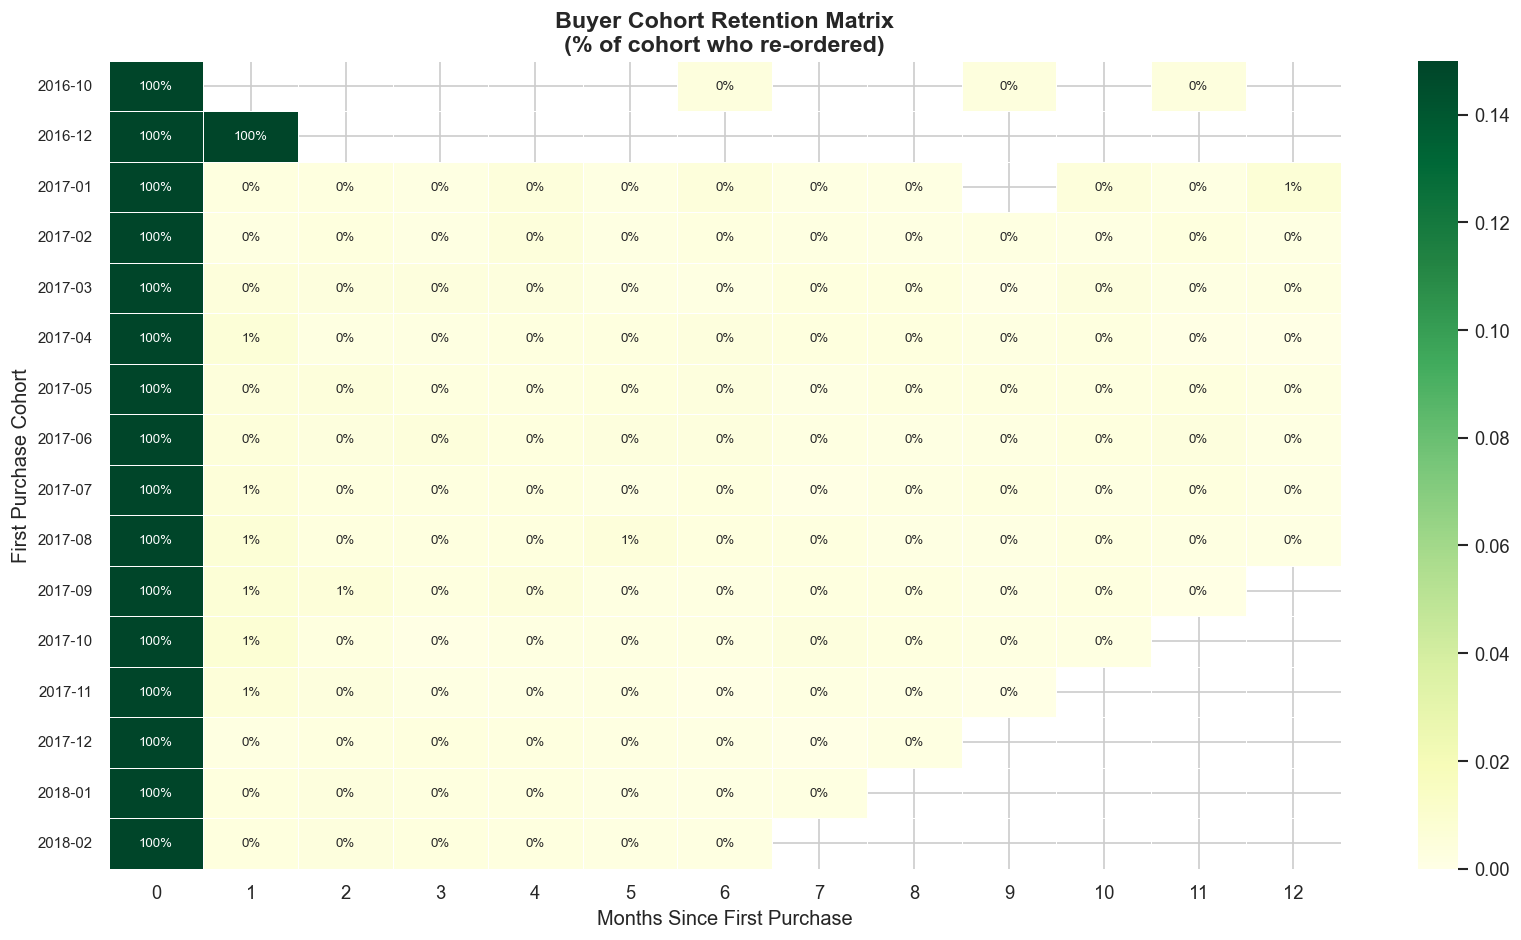

In [17]:
fig, ax = plt.subplots(figsize=(14, 8))
mask = recent_cohorts.isnull()
labels = recent_cohorts.applymap(lambda x: f'{x:.0%}' if pd.notna(x) else '')
sns.heatmap(recent_cohorts.fillna(0), ax=ax, cmap='YlGn',
            vmin=0, vmax=0.15,
            annot=labels, fmt='', annot_kws={'size': 8},
            linewidths=0.3, mask=mask)
ax.set_title('Buyer Cohort Retention Matrix\n(% of cohort who re-ordered)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('First Purchase Cohort')
ax.set_yticklabels([str(c) for c in recent_cohorts.index], rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../images/cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.5 Matching Efficiency: Orders per Active Seller per Category

**Matching efficiency** quantifies how well the supply side is meeting demand.
For each category, we track the monthly trend of orders per active seller.
A sudden drop signals sellers leaving without demand following — supply-side churn.
A sudden spike means demand surged but seller count didn't grow to match.


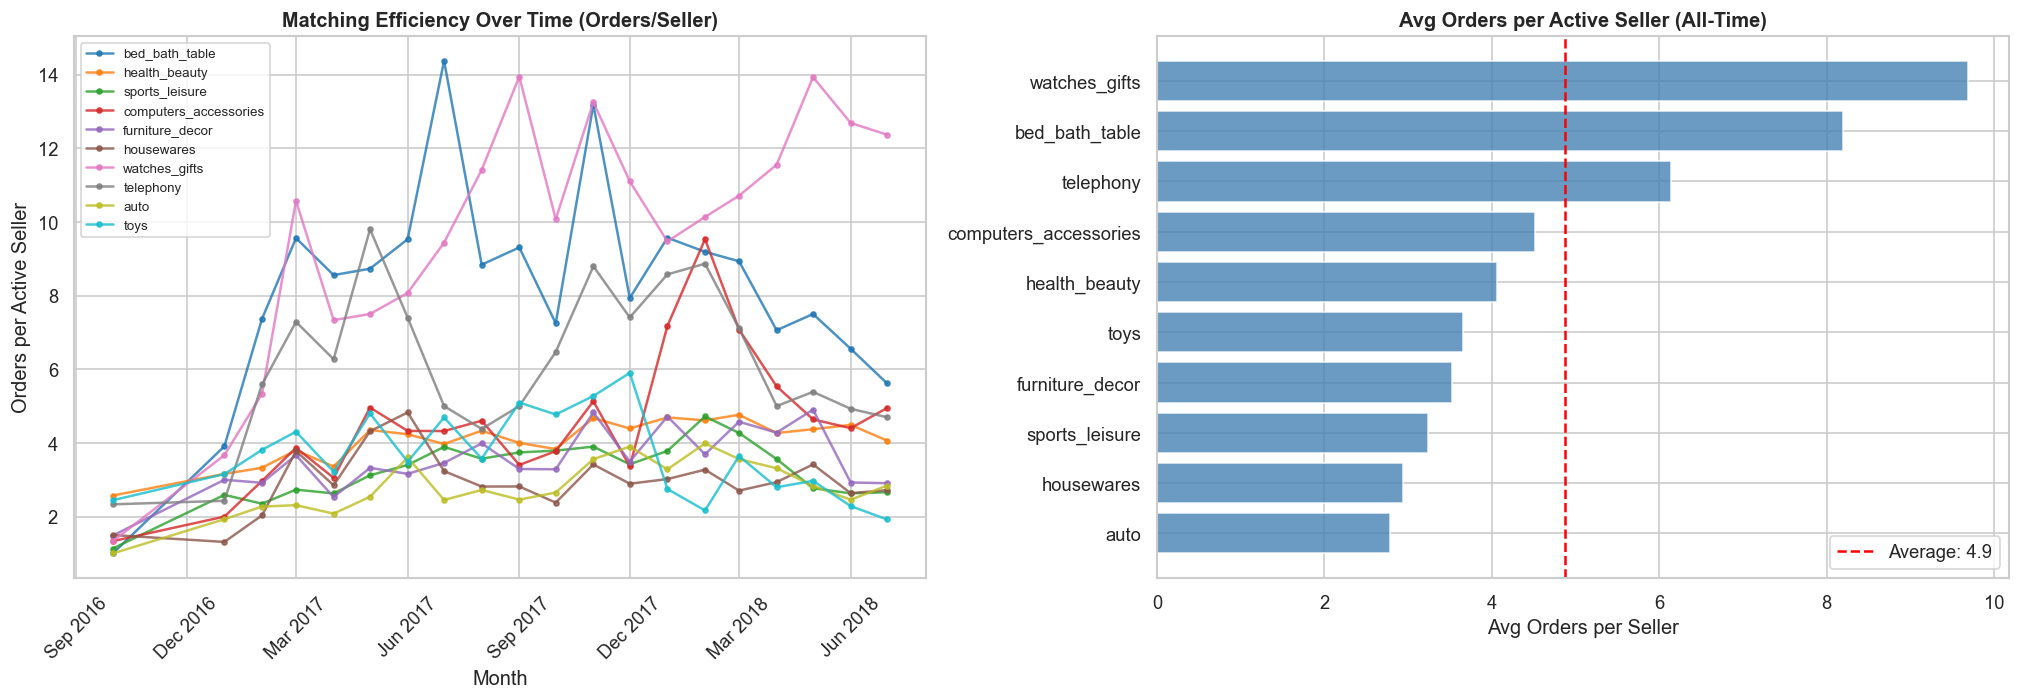

In [18]:
matching = (base[base['order_status']=='delivered']
            .groupby(['month','category'])
            .agg(orders=('order_id','nunique'), sellers=('seller_id','nunique'))
            .reset_index())
matching['orders_per_seller'] = matching['orders'] / matching['sellers']

# Filter to top 10 categories with most total orders
top10 = (base[base['order_status']=='delivered']
         .groupby('category')['order_id'].nunique()
         .nlargest(10).index.tolist())

matching_top = matching[
    (matching['category'].isin(top10)) &
    (matching['month'] > matching['month'].min()) &
    (matching['month'] < matching['month'].max())]

# Final comparison bar chart (avg orders/seller)
avg_match = (matching_top.groupby('category')['orders_per_seller']
             .mean().sort_values(ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Left: time series
colors = plt.cm.tab10.colors
for i, cat in enumerate(top10):
    sub = matching_top[matching_top['category']==cat]
    axes[0].plot(sub['month'], sub['orders_per_seller'],
                 linewidth=1.5, marker='.', alpha=0.8, color=colors[i], label=cat)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
axes[0].set_title('Matching Efficiency Over Time (Orders/Seller)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Orders per Active Seller')
axes[0].legend(fontsize=8, loc='upper left')

# Right: ranking bar
axes[1].barh(avg_match.index, avg_match.values, color='steelblue', alpha=0.8)
axes[1].axvline(avg_match.mean(), linestyle='--', color='red',
                label=f'Average: {avg_match.mean():.1f}')
axes[1].set_title('Avg Orders per Active Seller (All-Time)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Orders per Seller')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/matching_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()


## Layer 2 Drill-Down Summary

| Drill-Down | Key Finding Signal | Next Action |
|------------|-------------------|-------------|
| GMV by Category | Which category is falling? | → Investigate seller supply in that category |
| GMV by Region | Which region is declining? | → Check logistics performance in that region |
| Seller Churn | Rising churn rate? | → Trigger seller retention campaign |
| New Seller Acq | Slowing inflow? | → Boost seller recruitment spend |
| Cohort Retention | Low Month-1 return rate? | → Buyer re-engagement program |
| Matching Efficiency | Orders/seller dropping? | → Balance supply (reduce) or stimulate demand |

→ **Use `03_forecasting.ipynb` to project where these metrics are headed.**
